#FINE TUNING OF FOUNDATIONAL MODELS
---

##0.REFERENCE AND CONTEXT

**Introduction**

Foundation models have transformed artificial intelligence by providing large pretrained neural networks capable of understanding and generating language across a wide range of tasks. These models are trained on enormous corpora and acquire broad linguistic knowledge, reasoning capabilities, and factual information. However, despite their impressive generality, foundation models are not specialists. They do not automatically understand an organization's internal procedures, preferred communication styles, regulatory frameworks, or specialized domain knowledge.

Fine-tuning addresses this limitation by adapting a pretrained model to a specific domain. Rather than training a model from scratch, practitioners begin with a pretrained foundation model and perform additional training on domain-specific examples. This process allows the model to retain its general language capabilities while becoming significantly more effective in a specialized area.

In finance, fine-tuning is particularly valuable. Financial institutions require models capable of understanding concepts such as duration risk, yield curves, portfolio construction, inflation hedging, factor investing, risk budgeting, and performance attribution. While a general-purpose language model may have some familiarity with these topics, fine-tuning enables the model to develop a more consistent and specialized understanding.

This notebook demonstrates the complete fine-tuning workflow using DistilGPT2, a lightweight version of GPT-2 that can be trained efficiently on a Google Colab G4 environment. Students will construct a synthetic financial instruction dataset, prepare examples for supervised fine-tuning, train the model, evaluate performance, and compare behavior before and after adaptation.

The notebook also introduces several important concepts including instruction tuning, tokenization, train-validation splits, loss monitoring, and domain adaptation. Students will learn how fine-tuning differs from Retrieval-Augmented Generation and how the two techniques complement each other in production systems.

By the end of this chapter, students will understand how organizations transform general-purpose foundation models into specialized AI systems. This capability is one of the most important practical skills in modern AI engineering and serves as a foundation for advanced topics such as reasoning-model adaptation, multi-agent systems, and autonomous AI workflows.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the environment, installs the required libraries, establishes reproducibility, and creates project folders.

In [1]:
# CELL 1
# Environment Setup

!pip -q install transformers datasets accelerate evaluate

import json
import random
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path(
    "/content/chapter16_finetuning"
)

ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "model"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "PyTorch:",
    torch.__version__
)

print(
    "CUDA:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


##2.TRAINING DATASET WITH QUESTION AND ANSWER FORMAT

**Explanation for Cell 2**

This cell creates a synthetic financial instruction dataset containing question-answer pairs suitable for instruction tuning.

In [2]:
# CELL 2
# Create Synthetic Dataset

financial_topics = [

    "Sharpe Ratio",
    "Duration Risk",
    "Yield Curve",
    "Inflation",
    "Portfolio Diversification",
    "Risk Budgeting",
    "Factor Investing",
    "Tracking Error",
    "Alpha",
    "Beta"

]

examples = []

for topic in financial_topics:

    for i in range(50):

        instruction = (
            f"Explain {topic}"
        )

        response = (
            f"{topic} is an important "
            f"financial concept used in "
            f"investment management, "
            f"portfolio construction, "
            f"and risk analysis."
        )

        examples.append(
            {
                "instruction":
                    instruction,

                "response":
                    response
            }
        )

print(
    "Examples:",
    len(examples)
)

print(
    examples[0]
)

Examples: 500
{'instruction': 'Explain Sharpe Ratio', 'response': 'Sharpe Ratio is an important financial concept used in investment management, portfolio construction, and risk analysis.'}


##3.LOADING DISTILBERT GPT2

**Explanation for Cell 3**

This cell loads the DistilGPT2 foundation model and tokenizer.

In [3]:
# CELL 3
# Load Base Model

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

MODEL_NAME = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

print(
    "Model Loaded:",
    MODEL_NAME
)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model Loaded: distilgpt2


##4.FORMATTING THE INSTRUCTION RESPONSE PAIRS

**Explanation for Cell 4**

This cell converts instruction-response pairs into a format suitable for supervised fine-tuning.

In [4]:
# CELL 4
# Dataset Formatting

formatted_texts = []

for example in examples:

    text = (
        f"Instruction: "
        f"{example['instruction']}\n\n"
        f"Response: "
        f"{example['response']}"
    )

    formatted_texts.append(text)

print(
    formatted_texts[0]
)

Instruction: Explain Sharpe Ratio

Response: Sharpe Ratio is an important financial concept used in investment management, portfolio construction, and risk analysis.


##5.THE TRAIN AND VALIDATION SETS

**Explanation for Cell 5**

This cell creates train and validation datasets.

In [5]:
# CELL 5
# Train Validation Split

from datasets import Dataset

dataset = Dataset.from_dict(
    {
        "text":
            formatted_texts
    }
)

dataset = dataset.shuffle(
    seed=SEED
)

split = dataset.train_test_split(
    test_size=0.20,
    seed=SEED
)

train_dataset = split["train"]
validation_dataset = split["test"]

print(train_dataset)
print(validation_dataset)

Dataset({
    features: ['text'],
    num_rows: 400
})
Dataset({
    features: ['text'],
    num_rows: 100
})


##6.TOKENIZATION OF THE DATASET

**Explanation for Cell 6**

This cell tokenizes the dataset and prepares it for fine-tuning.

In [11]:
# CELL 6
# Tokenization for causal language modeling.
# IMPORTANT:
# Do not manually create labels.
# DataCollatorForLanguageModeling will create labels automatically.

MAX_LENGTH = 128

train_dataset = train_dataset.with_format(None)
validation_dataset = validation_dataset.with_format(None)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

train_dataset_tokenized = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

validation_dataset_tokenized = validation_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

train_dataset_tokenized = train_dataset_tokenized.with_format(None)
validation_dataset_tokenized = validation_dataset_tokenized.with_format(None)

print("Tokenization complete.")
print(train_dataset_tokenized)
print(validation_dataset_tokenized)

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenization complete.
Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 400
})
Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 100
})


##7.EXECUTION OF THE FINE TUNING PROCESS

**Explanation for Cell 7**

This cell configures and executes the fine-tuning process.

In [16]:
# CELL 7
# Fine-Tuning with DataCollatorForLanguageModeling.

from transformers import (
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

model.config.pad_token_id = tokenizer.pad_token_id

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

training_args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    num_train_epochs=30,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=5e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    report_to="none",
    seed=SEED,
    fp16=False,
    remove_unused_columns=False
)

try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset_tokenized,
        eval_dataset=validation_dataset_tokenized,
        processing_class=tokenizer,
        data_collator=data_collator
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset_tokenized,
        eval_dataset=validation_dataset_tokenized,
        data_collator=data_collator
    )

training_result = trainer.train()

training_metrics_path = ARTIFACT_DIR / "training_metrics.json"

with open(
    training_metrics_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        training_result.metrics,
        f,
        indent=2
    )

print("Training complete.")
print("Training metrics saved to:", training_metrics_path)

Epoch,Training Loss,Validation Loss
1,0.075735,0.081090
2,0.074748,0.079220
3,0.079334,0.079098
4,0.079433,0.078833
5,0.079392,0.078760
6,0.080797,0.078121
7,0.081581,0.079911
8,0.079906,0.080691
9,0.081800,0.081973
10,0.079874,0.078813


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.
Training metrics saved to: /content/chapter16_finetuning/artifacts/training_metrics.json


##8.EVALUATION OF FINE TUNED MODEL

**Explanation for Cell 8**

This cell evaluates the fine-tuned DistilGPT2 model on the validation dataset. The purpose is to obtain a quantitative measure of how well the model predicts the next token after fine-tuning. For causal language models, the primary evaluation metric is loss. A lower evaluation loss means the model is better at assigning probability to the expected continuation of the training examples.

The cell also computes perplexity, which is the exponential transformation of loss. Perplexity can be interpreted as a measure of how uncertain the model is when predicting the next token. Lower perplexity indicates better language modeling performance. The results are saved as a JSON artifact so that the GPT-5.2 explanation cell can later interpret them.

In [17]:
# CELL 8
# Evaluation of Fine-Tuned Model

evaluation_results = trainer.evaluate(
    eval_dataset=validation_dataset_tokenized
)

eval_loss = float(
    evaluation_results.get(
        "eval_loss",
        np.nan
    )
)

if np.isfinite(eval_loss):
    perplexity = float(
        np.exp(eval_loss)
    )
else:
    perplexity = None

evaluation_summary = {
    "model": MODEL_NAME,
    "evaluation_loss": eval_loss,
    "perplexity": perplexity,
    "validation_examples": int(len(validation_dataset_tokenized)),
    "max_length": int(MAX_LENGTH)
}

evaluation_results_path = (
    ARTIFACT_DIR /
    "evaluation_results.json"
)

with open(
    evaluation_results_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        evaluation_summary,
        f,
        indent=2
    )

print("Evaluation Results")
print(json.dumps(evaluation_summary, indent=2))

print("\nSaved evaluation results to:", evaluation_results_path)

Training Loss,Validation Loss,Epoch
0.078112,0.078066,30


Evaluation Results
{
  "model": "distilgpt2",
  "evaluation_loss": 0.07806635648012161,
  "perplexity": 1.081194400544535,
  "validation_examples": 100,
  "max_length": 128
}

Saved evaluation results to: /content/chapter16_finetuning/artifacts/evaluation_results.json


##9.BEFORE AND AFTER COMPARISON

**Explanation for Cell 9**

This cell compares model behavior before and after fine-tuning. The notebook has already fine-tuned the model, so this cell loads a fresh copy of the original DistilGPT2 model as the baseline. The same finance-oriented prompts are sent to both models. This allows students to see whether fine-tuning made the model more consistent with the financial advisory style in the synthetic instruction dataset.

The goal is not to prove that the small fine-tuned model is a professional financial advisor. The goal is to demonstrate the mechanics of domain adaptation: the same base model can produce more domain-aligned responses after additional training on specialized examples.

In [19]:
# CELL 9
# Before vs After Fine-Tuning Comparison

from transformers import AutoModelForCausalLM

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

base_model.config.pad_token_id = tokenizer.pad_token_id
model.config.pad_token_id = tokenizer.pad_token_id

base_model.to(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(
    "cuda" if torch.cuda.is_available() else "cpu"
)

base_model.eval()
model.eval()

comparison_prompts = [
    "Instruction: Explain Duration Risk\n\nResponse:",
    "Instruction: Explain Sharpe Ratio\n\nResponse:",
    "Instruction: Explain Portfolio Diversification\n\nResponse:",
    "Instruction: Explain Tracking Error\n\nResponse:"
]

def generate_response(
    generation_model,
    prompt,
    max_new_tokens=60
):
    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(generation_model.device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = generation_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return decoded

comparison_records = []

for prompt in comparison_prompts:
    base_response = generate_response(
        base_model,
        prompt
    )

    fine_tuned_response = generate_response(
        model,
        prompt
    )

    comparison_records.append(
        {
            "prompt": prompt,
            "base_model_response": base_response,
            "fine_tuned_model_response": fine_tuned_response
        }
    )

comparison_path = (
    ARTIFACT_DIR /
    "before_after_comparison.json"
)

with open(
    comparison_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        comparison_records,
        f,
        indent=2
    )

for record in comparison_records:
    print("=" * 80)
    print("PROMPT")
    print(record["prompt"])

    print("\nBASE MODEL RESPONSE")
    print(record["base_model_response"])

    print("\nFINE-TUNED MODEL RESPONSE")
    print(record["fine_tuned_model_response"])

print("\nSaved before-after comparison to:", comparison_path)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

PROMPT
Instruction: Explain Duration Risk

Response:

BASE MODEL RESPONSE
Instruction: Explain Duration Risk

Response:
The following is a summary of the following:
The following is a summary of the following:
The following is a summary of the following:
The following is a summary of the following:
The following is a summary of the following:
The following is a summary of the following:

FINE-TUNED MODEL RESPONSE
Instruction: Explain Duration Risk

Response: Duration Risk is an important financial concept used in investment management, portfolio construction, and risk analysis. Duration Risk is an important financial concept used in investment management, and risk analysis. Duration Risk is an important financial concept used in investment management, portfolio construction, and risk analysis.
Response: Duration Risk is
PROMPT
Instruction: Explain Sharpe Ratio

Response:

BASE MODEL RESPONSE
Instruction: Explain Sharpe Ratio

Response:
The Sharpe Ratio is a measure of the number of tim

##10.TRAINING METRICS

**Explanation for Cell 10**

This cell visualizes the training metrics recorded by Hugging Face Trainer. It extracts training loss and evaluation loss from the trainer log history, saves the metrics, and plots the learning curve. The purpose is to help students inspect whether the model actually learned during fine-tuning.

The training curve is especially important in fine-tuning. If loss falls too quickly and validation loss worsens, the model may be overfitting. If loss does not fall at all, the learning rate may be too low or the dataset may not provide a clear signal. In this small synthetic example, the curve should be interpreted pedagogically rather than as evidence of production-grade performance.

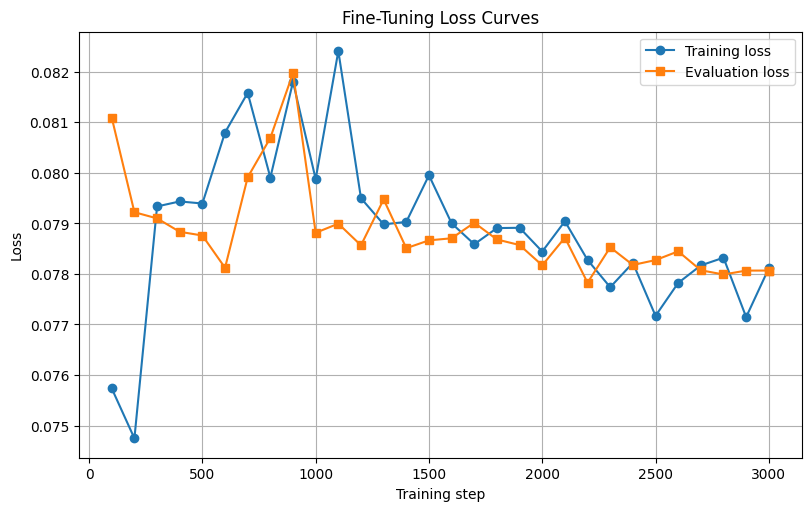

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved training log history to: /content/chapter16_finetuning/artifacts/training_log_history.json
Saved loss curve to: /content/chapter16_finetuning/artifacts/fine_tuning_loss_curve.png
Saved fine-tuned model to: /content/chapter16_finetuning/model/distilgpt2_financial_finetuned
Saved artifact index to: /content/chapter16_finetuning/artifacts/artifact_index.json


In [20]:
# CELL 10
# Training Metrics and Loss Curves

log_history = trainer.state.log_history

training_loss_records = []
evaluation_loss_records = []

for entry in log_history:
    if "loss" in entry:
        training_loss_records.append(
            {
                "step": int(entry.get("step", len(training_loss_records))),
                "loss": float(entry["loss"])
            }
        )

    if "eval_loss" in entry:
        evaluation_loss_records.append(
            {
                "step": int(entry.get("step", len(evaluation_loss_records))),
                "eval_loss": float(entry["eval_loss"])
            }
        )

metrics_summary = {
    "training_loss_records": training_loss_records,
    "evaluation_loss_records": evaluation_loss_records
}

metrics_path = (
    ARTIFACT_DIR /
    "training_log_history.json"
)

with open(
    metrics_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metrics_summary,
        f,
        indent=2
    )

fig, ax = plt.subplots(
    figsize=(8, 5),
    constrained_layout=True
)

if len(training_loss_records) > 0:
    ax.plot(
        [record["step"] for record in training_loss_records],
        [record["loss"] for record in training_loss_records],
        marker="o",
        label="Training loss"
    )

if len(evaluation_loss_records) > 0:
    ax.plot(
        [record["step"] for record in evaluation_loss_records],
        [record["eval_loss"] for record in evaluation_loss_records],
        marker="s",
        label="Evaluation loss"
    )

ax.set_title("Fine-Tuning Loss Curves")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.grid(True)
ax.legend()

loss_curve_path = (
    ARTIFACT_DIR /
    "fine_tuning_loss_curve.png"
)

fig.savefig(
    loss_curve_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

model_save_path = MODEL_DIR / "distilgpt2_financial_finetuned"

trainer.save_model(
    str(model_save_path)
)

tokenizer.save_pretrained(
    str(model_save_path)
)

artifact_index = {
    "model_name": MODEL_NAME,
    "run_id": RUN_ID if "RUN_ID" in globals() else None,
    "evaluation_results_path": str(evaluation_results_path),
    "comparison_path": str(comparison_path),
    "metrics_path": str(metrics_path),
    "loss_curve_path": str(loss_curve_path),
    "model_save_path": str(model_save_path)
}

artifact_index_path = (
    ARTIFACT_DIR /
    "artifact_index.json"
)

with open(
    artifact_index_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        artifact_index,
        f,
        indent=2
    )

print("Saved training log history to:", metrics_path)
print("Saved loss curve to:", loss_curve_path)
print("Saved fine-tuned model to:", model_save_path)
print("Saved artifact index to:", artifact_index_path)

##11.EVALUATION AND SUMMARIZATION

In [21]:
# CELL 11
# GPT-5.2 Analysis of Fine-Tuning Results

import re
from google.colab import userdata
from openai import OpenAI

OPENAI_MODEL = "gpt-5.2"

api_key = userdata.get(
    "OPENAI_API_KEY"
)

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY was not found in Colab Secrets."
    )

client = OpenAI(
    api_key=api_key
)

with open(
    evaluation_results_path,
    "r",
    encoding="utf-8"
) as f:
    evaluation_for_llm = json.load(f)

with open(
    comparison_path,
    "r",
    encoding="utf-8"
) as f:
    comparison_for_llm = json.load(f)

with open(
    metrics_path,
    "r",
    encoding="utf-8"
) as f:
    metrics_for_llm = json.load(f)

compact_results = {
    "model": MODEL_NAME,
    "fine_tuning_objective": "Domain adaptation of DistilGPT2 to synthetic financial instruction-response examples",
    "training_examples": int(len(train_dataset_tokenized)),
    "validation_examples": int(len(validation_dataset_tokenized)),
    "max_length": int(MAX_LENGTH),
    "evaluation": evaluation_for_llm,
    "before_after_comparison": comparison_for_llm,
    "training_metrics": metrics_for_llm,
    "artifacts": {
        "evaluation_results_path": str(evaluation_results_path),
        "comparison_path": str(comparison_path),
        "metrics_path": str(metrics_path),
        "loss_curve_path": str(loss_curve_path),
        "model_save_path": str(model_save_path)
    }
}

system_prompt = """
You are a machine learning instructor.
Explain a foundation-model fine-tuning experiment using DistilGPT2.
Return strict JSON only.
Do not invent results.
Separate observed facts from interpretation.
Mention that the dataset is synthetic and educational.
Mention that this is not a production financial advisory model.
"""

user_prompt = f"""
Analyze the following fine-tuning experiment.

Return JSON with this schema:

{{
  "plain_english_summary": "string",
  "what_was_fine_tuned": "string",
  "what_the_dataset_teaches": "string",
  "evaluation_loss_interpretation": "string",
  "perplexity_interpretation": "string",
  "before_after_comparison": "string",
  "evidence_used": ["string"],
  "assumptions": ["string"],
  "limitations": ["string"],
  "recommended_next_steps": ["string"],
  "verification_status": "Not verified by external data"
}}

Experiment results:

BEGIN_RESULTS_JSON
{json.dumps(compact_results, indent=2)}
END_RESULTS_JSON
"""

response = client.responses.create(
    model=OPENAI_MODEL,
    input=[
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]
)

llm_text = response.output_text.strip()

def extract_json_object(text):
    text = text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    first = text.find("{")
    last = text.rfind("}")

    if first == -1 or last == -1 or last <= first:
        raise ValueError(
            "No JSON object found in LLM response."
        )

    candidate = text[first:last + 1]

    return json.loads(candidate)

llm_explanation = extract_json_object(
    llm_text
)

llm_explanation_path = (
    ARTIFACT_DIR /
    "llm_fine_tuning_explanation.json"
)

with open(
    llm_explanation_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        llm_explanation,
        f,
        indent=2
    )

print(
    json.dumps(
        llm_explanation,
        indent=2
    )
)

print(
    "\nLLM explanation saved to:",
    llm_explanation_path
)

{
  "plain_english_summary": "DistilGPT2 was fine-tuned on a small, synthetic, educational dataset of financial instruction\u2192response examples (400 train / 100 validation, max_length 128) to encourage it to answer finance-flavored prompts in an instruction-following style. The reported validation evaluation loss is 0.0781 with perplexity 1.0812, and the included prompt comparisons show the fine-tuned model shifts from generic/repetitive or off-topic outputs toward finance-themed boilerplate responses\u2014though it still shows repetition and occasional topic drift. This is a synthetic educational exercise and not a production financial advisory model.",
  "what_was_fine_tuned": "A foundation language model, distilgpt2, was fine-tuned for domain adaptation on synthetic financial instruction-response examples (instruction-style prompts like 'Explain Sharpe Ratio' and corresponding responses).",
  "what_the_dataset_teaches": "Observed facts: The stated objective is 'Domain adaptation 

##12.CONCLUSIONS

**Conclusion**

This notebook demonstrated the complete workflow for fine-tuning a foundation model. Students began with a pretrained DistilGPT2 model and adapted it to a specialized financial advisory domain using a synthetic instruction dataset. This process illustrated one of the most important capabilities in modern AI engineering: transforming general-purpose models into domain-specific experts.

Several key concepts were introduced. Students learned how instruction datasets are constructed, how examples are tokenized, how training and validation datasets are created, and how supervised fine-tuning is performed. The notebook also demonstrated how training loss can be monitored and how model behavior changes after adaptation.

Fine-tuning differs from Retrieval-Augmented Generation in an important way. RAG adds external knowledge at inference time, while fine-tuning modifies the model itself. Organizations frequently combine both approaches. Fine-tuning teaches domain-specific behavior and style, while RAG provides access to dynamic information and proprietary documents. Together they form the foundation of many production AI systems.

Students also observed the practical tradeoffs associated with model adaptation. Fine-tuning can improve specialization, consistency, and performance on domain-specific tasks. However, excessive fine-tuning may lead to overfitting or catastrophic forgetting. Understanding these tradeoffs is essential for responsible AI engineering.

This chapter represents an important milestone in the curriculum because students are no longer merely using pretrained models. They are actively modifying and adapting foundation models to new domains. This capability is central to enterprise AI development and serves as a bridge toward more advanced model customization techniques.

The next chapter extends these ideas into Fine-Tuning Reasoning Models. Whereas this notebook focused primarily on knowledge adaptation, the next notebook explores how reasoning processes themselves can be modified and improved through specialized training data. This transition introduces students to one of the most active research areas in modern artificial intelligence.